In [13]:
#### Importing required libraries

In [14]:
import matplotlib.pyplot as plt 
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
import seaborn as sns
import pandas as pd
import matplotlib.pylab as plt
from utils import Hetero_Data_Processor_Filter_on_Test_since_first_post
import warnings 
warnings.filterwarnings("ignore")
import os
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

In [15]:
event_name ="charlie_hebdo"
df_posts_by_time_cut = pd.read_pickle(f'replies_{event_name}.pkl')

df_posts_by_time_cut['min_since_fst_post'] = round(
            (df_posts_by_time_cut['time'] - df_posts_by_time_cut['time'].min()).dt.total_seconds() / 60, 2)


In [16]:
df_metrics = df_posts_by_time_cut[['id','time','rumour','min_since_fst_post']].drop_duplicates().sort_values(by='time')

In [17]:
file_path_replies = f"replies_{event_name}.pkl"
file_path_posts = f"posts_{event_name}.pkl"


processor = Hetero_Data_Processor_Filter_on_Test_since_first_post(file_path_replies, file_path_posts, time_cut=10000)
data = processor.process()


In [18]:

start = df_metrics.iloc[int(data['id'].train_mask.sum()):].min_since_fst_post.min()
end = df_metrics.iloc[int(data['id'].train_mask.sum()):].min_since_fst_post.max()
duration = end-start
experiment_time= duration+60
print("Experiment Start", round(start/60,2), 'hours after first post')
print("Experiment End:", round(end/60,2),'hours after first post')
print("Duration", round(experiment_time/60,2),'hours')

Experiment Start 29.77 hours after first post
Experiment End: 53.58 hours after first post
Duration 24.81 hours


In [19]:
bad_rate_train = df_metrics.iloc[:int(data['id'].train_mask.sum())]['rumour'].sum()\
                    /df_metrics.iloc[:int(data['id'].train_mask.sum())].shape[0]

bad_rate_test = df_metrics.iloc[int(data['id'].train_mask.sum()):].rumour.sum()\
            /df_metrics.iloc[int(data['id'].train_mask.sum()):].shape[0]

print("Bad_rate Train",bad_rate_train)
print("Bad_rate Test",bad_rate_test)


Bad_rate Train 0.15285714285714286
Bad_rate Test 0.3876871880199667


In [20]:
cut=int(bad_rate_train/2*100)
print(cut)

7


#### HAN model

In [21]:
experiment = mlflow.get_experiment_by_name(f'HAN 2026-07-04 {event_name}')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_han = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")


HAN 2026-07-04 charlie_hebdo


In [22]:
dfs=[]

for run_id in list(df_han.run_id):
    try:
        path = mlflow.artifacts.download_artifacts(
            run_id=run_id,
            artifact_path=f"metrics_by_bucket_new_posts_{event_name}_HAN.csv"
        )
        df = pd.read_csv(path)
        df["run_id"] = run_id  # track source
        #print(df.shape)
        #df["time_cut"] =df_gat[df_gat.run_id==run_id]['metrics.time_cut']

        dfs.append(df)
    except Exception:
        pass  # skip runs without the artifact

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.merge(df_han[['run_id','metrics.time_cut']],on='run_id',how='left')
df_all.rename(columns={'Rumours_captured':'frauds_captured'},inplace=True)

In [23]:
df_all.sort_values(by='metrics.time_cut',ascending=True,inplace=True)

In [24]:
df_all['hour']= round(df_all['metrics.time_cut']/60,2)
df_posts_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['records'].max())
df_fakes_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['frauds_captured'].max())
df_posts_by_time_cut.rename(columns={'records':'total_posts'},inplace=True)
df_fakes_by_time_cut.rename(columns={'frauds_captured':'total_fake'},inplace=True)
df_all = df_all.merge(df_posts_by_time_cut, on='metrics.time_cut',how='left')
df_all = df_all.merge(df_fakes_by_time_cut, on='metrics.time_cut',how='left')
df_all.capture_rate = round(df_all.capture_rate,3)
df_all.false_positive_rate = round(df_all.false_positive_rate,3)
df_all = df_all[(df_all['percentile']==cut)]

df_all['false_positive_rate'] = (df_all['records']-df_all['frauds_captured'])/\
                    ( (df_all['records']-df_all['frauds_captured']) +  (df_all['total_posts']-df_all['records']) )

df_all['capture_rate'] =df_all['frauds_captured']/df_all['total_fake']

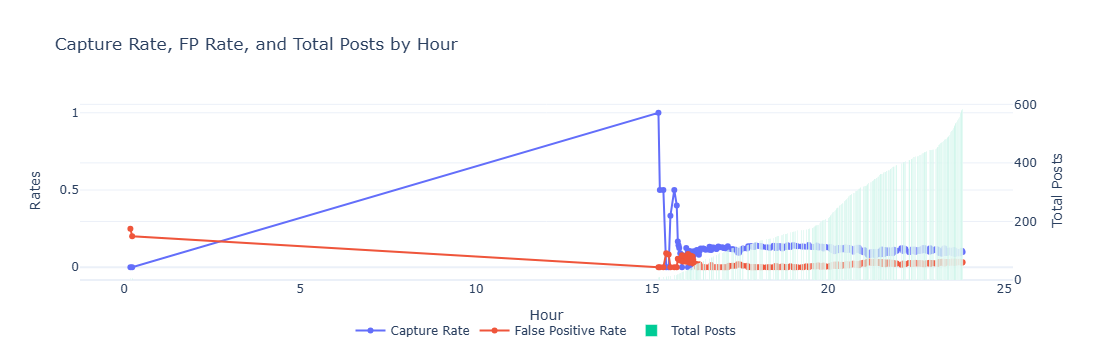

In [25]:

import plotly.graph_objects as go

fig = go.Figure()

# Capture Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["capture_rate"],
        mode="lines+markers",
        name="Capture Rate",
        yaxis="y1"
    )
)

# Bad Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["false_positive_rate"],
        mode="lines+markers",
        name="False Positive Rate",
        yaxis="y1"
    )
)

# Total Posts (secondary axis)
fig.add_trace(
    go.Bar(
        x=df_all["hour"],
        y=df_all["total_posts"],
        name="Total Posts",
        # mode="lines+markers",
        yaxis="y2",
        opacity=1
    )
)

# Layout with dual axis
fig.update_layout(
    title="Capture Rate, FP Rate, and Total Posts by Hour",
    xaxis=dict(title="Hour"),
    yaxis=dict(title="Rates", side="left"),
    yaxis2=dict(
        title="Total Posts",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",      # horizontal legend
        yanchor="top",
        y=-0.2,               # move below plot
        xanchor="center",
        x=0.5                 # center horizontally
    ),
    template="plotly_white"
)

fig.show()

In [26]:
print("bad_rate_test",round(bad_rate_test*100,2))
print('Rumour Capture rate: ',float(round(df_all.frauds_captured.sum()/df_all.total_fake.sum()*100,2)))
print('False Positive rate: ',float(round((df_all.records.sum()- df_all.frauds_captured.sum())/df_all.total_posts.sum()*100,2)))

bad_rate_test 38.77
Rumour Capture rate:  10.93
False Positive rate:  2.19


In [27]:
df_han_all =df_all.copy()
#df_han_all = df_han_all[df_han_all.total_posts/df_han_all.total_posts.max()>=0.1]
df_han_all['model'] ='HAN'

#### GAT model

In [28]:
experiment = mlflow.get_experiment_by_name(f'GAT 2026-06-06 {event_name}')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_gat = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='metrics.time_cut')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")


GAT 2026-06-06 charlie_hebdo


In [29]:
experiment = mlflow.get_experiment_by_name(f'GAT 2026-05-26 {event_name} run')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_gat = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='metrics.time_cut')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")


GAT 2026-05-26 charlie_hebdo run


In [30]:
dfs=[]

for run_id in list(df_gat.run_id):
    try:
        path = mlflow.artifacts.download_artifacts(
            run_id=run_id,
            artifact_path=f"metrics_by_bucket_new_posts_{event_name}_GAT.csv"
        )
        df = pd.read_csv(path)
        df["run_id"] = run_id  # track source
        #df["time_cut"] =df_gat[df_gat.run_id==run_id]['metrics.time_cut']

        dfs.append(df)
    except Exception:
        pass  # skip runs without the artifact

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.merge(df_gat[['run_id','metrics.time_cut']],on='run_id',how='left')
df_all.rename(columns={'Rumours_captured':'frauds_captured'},inplace=True)
df_all.sort_values(by='metrics.time_cut',ascending=True,inplace=True)

In [31]:
df_all['hour']= round(df_all['metrics.time_cut']/60,2)
df_posts_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['records'].max())
df_fakes_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['frauds_captured'].max())
df_posts_by_time_cut.rename(columns={'records':'total_posts'},inplace=True)
df_fakes_by_time_cut.rename(columns={'frauds_captured':'total_fake'},inplace=True)
df_all = df_all.merge(df_posts_by_time_cut, on='metrics.time_cut',how='left')
df_all = df_all.merge(df_fakes_by_time_cut, on='metrics.time_cut',how='left')
df_all.capture_rate = round(df_all.capture_rate,3)
df_all.false_positive_rate = round(df_all.false_positive_rate,3)
df_all = df_all[(df_all['percentile']==cut)]


df_all['total_posts'] = df_all.total_posts.cumsum()
df_all['total_fake'] = df_all.total_fake.cumsum()
df_all['frauds_captured'] = df_all.frauds_captured.cumsum()
df_all['records'] = df_all.records.cumsum()
df_all['capture_rate'] = df_all['frauds_captured'] /df_all['total_fake'] 
df_all['false_positive_rate'] = (df_all['records']-df_all['frauds_captured'])/\
                    ( (df_all['records']-df_all['frauds_captured']) +  (df_all['total_posts']-df_all['records']) )


df_all['false_positive_rate'] = (df_all['records']-df_all['frauds_captured'])/\
                    ( (df_all['records']-df_all['frauds_captured']) +  (df_all['total_posts']-df_all['records']) )

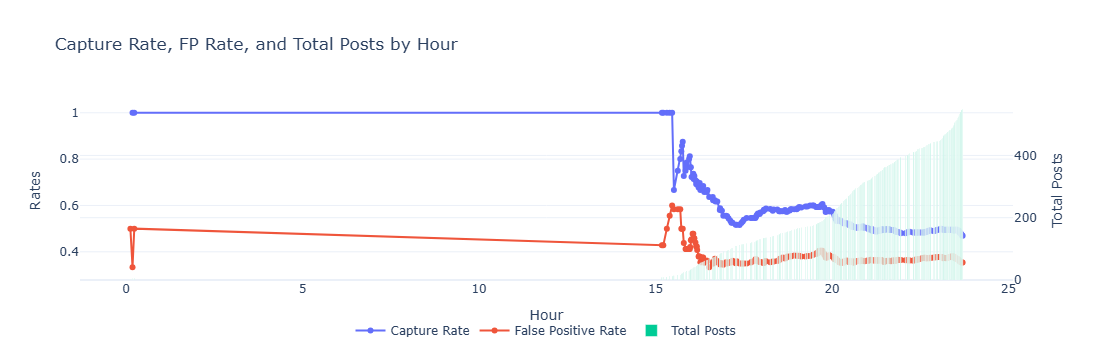

In [32]:

import plotly.graph_objects as go

fig = go.Figure()

# Capture Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["capture_rate"],
        mode="lines+markers",
        name="Capture Rate",
        yaxis="y1"
    )
)

# Bad Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["false_positive_rate"],
        mode="lines+markers",
        name="False Positive Rate",
        yaxis="y1"
    )
)

# Total Posts (secondary axis)
fig.add_trace(
    go.Bar(
        x=df_all["hour"],
        y=df_all["total_posts"],
        name="Total Posts",
        # mode="lines+markers",
        yaxis="y2",
        opacity=1
    )
)

# Layout with dual axis
fig.update_layout(
    title="Capture Rate, FP Rate, and Total Posts by Hour",
    xaxis=dict(title="Hour"),
    yaxis=dict(title="Rates", side="left"),
    yaxis2=dict(
        title="Total Posts",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",      # horizontal legend
        yanchor="top",
        y=-0.2,               # move below plot
        xanchor="center",
        x=0.5                 # center horizontally
    ),
    template="plotly_white"
)

fig.show()

In [33]:
print("bad_rate_test",round(bad_rate_test*100,2))
print('Rumour Capture rate: ',float(round(df_all.frauds_captured.sum()/df_all.total_fake.sum()*100,2)))
print('False Positive rate: ',float(round((df_all.records.sum()- df_all.frauds_captured.sum())/df_all.total_posts.sum()*100,2)))

bad_rate_test 38.77
Rumour Capture rate:  51.78
False Positive rate:  28.05


In [34]:
df_gat_all =df_all.copy()
#df_gat_all = df_gat_all[df_gat_all.total_posts/df_gat_all.total_posts.max()>=0.1]
df_gat_all['model'] ='GAT'

#### LSTM model

In [35]:
experiment = mlflow.get_experiment_by_name(f"LSTM 2026-07-11 {event_name}")
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_lstm = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")


LSTM 2026-07-11 charlie_hebdo


In [36]:
dfs=[]

for run_id in list(df_lstm.run_id):
    try:
        path = mlflow.artifacts.download_artifacts(
            run_id=run_id,
            artifact_path=f"metrics_by_bucket_new_posts_{event_name}_LSTM.csv"
        )
        df = pd.read_csv(path)
        df["run_id"] = run_id  # track source
        #print(df.shape)
        #df["time_cut"] =df_gat[df_gat.run_id==run_id]['metrics.time_cut']

        dfs.append(df)
    except Exception:
        pass  # skip runs without the artifact

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.merge(df_lstm[['run_id','metrics.time_cut']],on='run_id',how='left')
df_all.sort_values(by='metrics.time_cut',ascending=True,inplace=True)
df_all.rename(columns={'Rumours_captured':'frauds_captured'},inplace=True)

In [37]:
df_all['metrics.time_cut'].max()

np.float64(1419.0)

In [38]:
df_all['hour']= round(df_all['metrics.time_cut']/60,2)
df_posts_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['records'].max())
df_fakes_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['frauds_captured'].max())
df_posts_by_time_cut.rename(columns={'records':'total_posts'},inplace=True)
df_fakes_by_time_cut.rename(columns={'frauds_captured':'total_fake'},inplace=True)
df_all = df_all.merge(df_posts_by_time_cut, on='metrics.time_cut',how='left')
df_all = df_all.merge(df_fakes_by_time_cut, on='metrics.time_cut',how='left')
df_all.capture_rate = round(df_all.capture_rate,3)
df_all.false_positive_rate = round(df_all.false_positive_rate,3)
#df_all = df_all[df_all['total_posts']<=20]
df_all = df_all[(df_all['percentile']==cut)]


df_all['total_posts'] = df_all.total_posts.cumsum()
df_all['total_fake'] = df_all.total_fake.cumsum()
df_all['frauds_captured'] = df_all.frauds_captured.cumsum()
df_all['records'] = df_all.records.cumsum()
df_all['capture_rate'] = df_all['frauds_captured'] /df_all['total_fake'] 
df_all['false_positive_rate'] = (df_all['records']-df_all['frauds_captured'])/\
                    ( (df_all['records']-df_all['frauds_captured']) +  (df_all['total_posts']-df_all['records']) )


df_all['false_positive_rate'] = (df_all['records']-df_all['frauds_captured'])/\
                    ( (df_all['records']-df_all['frauds_captured']) +  (df_all['total_posts']-df_all['records']) )

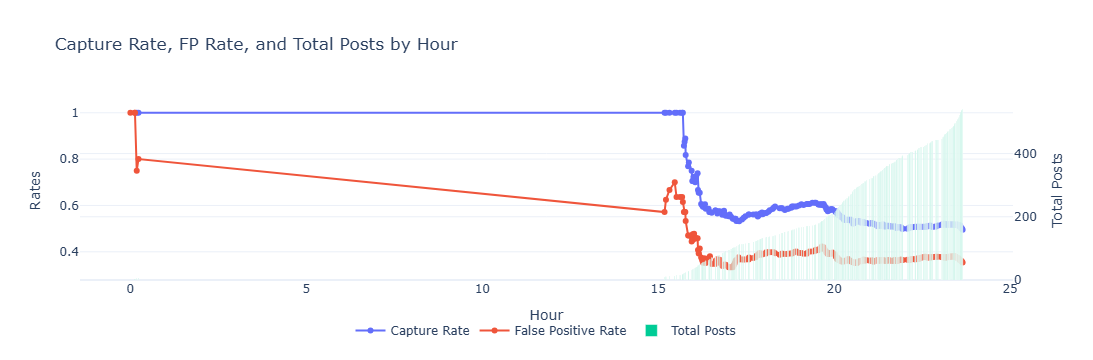

In [39]:

import plotly.graph_objects as go

fig = go.Figure()

# Capture Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["capture_rate"],
        mode="lines+markers",
        name="Capture Rate",
        yaxis="y1"
    )
)

# Bad Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["false_positive_rate"],
        mode="lines+markers",
        name="False Positive Rate",
        yaxis="y1"
    )
)

# Total Posts (secondary axis)
fig.add_trace(
    go.Bar(
        x=df_all["hour"],
        y=df_all["total_posts"],
        name="Total Posts",
        # mode="lines+markers",
        yaxis="y2",
        opacity=1
    )
)

# Layout with dual axis
fig.update_layout(
    title="Capture Rate, FP Rate, and Total Posts by Hour",
    xaxis=dict(title="Hour"),
    yaxis=dict(title="Rates", side="left"),
    yaxis2=dict(
        title="Total Posts",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",      # horizontal legend
        yanchor="top",
        y=-0.2,               # move below plot
        xanchor="center",
        x=0.5                 # center horizontally
    ),
    template="plotly_white"
)

fig.show()

In [40]:
print("bad_rate_test",round(bad_rate_test*100,2))
print('Rumour Capture rate: ',float(round(df_all.frauds_captured.sum()/df_all.total_fake.sum()*100,2)))
print('False Positive rate: ',float(round((df_all.records.sum()- df_all.frauds_captured.sum())/df_all.total_posts.sum()*100,2)))

bad_rate_test 38.77
Rumour Capture rate:  53.41
False Positive rate:  28.07


In [41]:
df_lstm_all=df_all.copy()
#df_lstm_all = df_lstm_all[df_lstm_all.total_posts/df_lstm_all.total_posts.max()>=0.1]
df_lstm_all['model']='LSTM'

#### Light GBM model

In [42]:
experiment = mlflow.get_experiment_by_name(f'Light GBM 2026-05-25 {event_name} run')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_lgb = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")


Light GBM 2026-05-25 charlie_hebdo run


In [43]:
dfs=[]

for run_id in list(df_lgb.run_id):
    try:
        path = mlflow.artifacts.download_artifacts(
            run_id=run_id,
            artifact_path=f"metrics_by_bucket_new_posts_{event_name}_LGBM.csv"
        )
        df = pd.read_csv(path)
        df["run_id"] = run_id  # track source
        #print(df.shape)
        #df["time_cut"] =df_gat[df_gat.run_id==run_id]['metrics.time_cut']

        dfs.append(df)
    except Exception:
        pass  # skip runs without the artifact

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.merge(df_lgb[['run_id','metrics.time_cut']],on='run_id',how='left')
df_all.sort_values(by='metrics.time_cut',ascending=True,inplace=True)
df_all.rename(columns={'Rumours_captured':'frauds_captured'},inplace=True)

In [44]:
df_all.sort_values(by='metrics.time_cut',ascending=True,inplace=True)

df_all['hour']= round(df_all['metrics.time_cut']/60,2)
df_posts_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['records'].max())
df_fakes_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['frauds_captured'].max())
df_posts_by_time_cut.rename(columns={'records':'total_posts'},inplace=True)
df_fakes_by_time_cut.rename(columns={'frauds_captured':'total_fake'},inplace=True)
df_all = df_all.merge(df_posts_by_time_cut, on='metrics.time_cut',how='left')
df_all = df_all.merge(df_fakes_by_time_cut, on='metrics.time_cut',how='left')
df_all.capture_rate = round(df_all.capture_rate,3)
df_all.false_positive_rate = round(df_all.false_positive_rate,3)
df_all = df_all[(df_all['percentile']==cut)]


df_all['total_posts'] = df_all.total_posts.cumsum()
df_all['total_fake'] = df_all.total_fake.cumsum()
df_all['frauds_captured'] = df_all.frauds_captured.cumsum()
df_all['records'] = df_all.records.cumsum()
df_all['capture_rate'] = df_all['frauds_captured'] /df_all['total_fake'] 
df_all['false_positive_rate'] = (df_all['records']-df_all['frauds_captured'])/\
                    ( (df_all['records']-df_all['frauds_captured']) +  (df_all['total_posts']-df_all['records']) )


df_all['false_positive_rate'] = (df_all['records']-df_all['frauds_captured'])/\
                    ( (df_all['records']-df_all['frauds_captured']) +  (df_all['total_posts']-df_all['records']) )

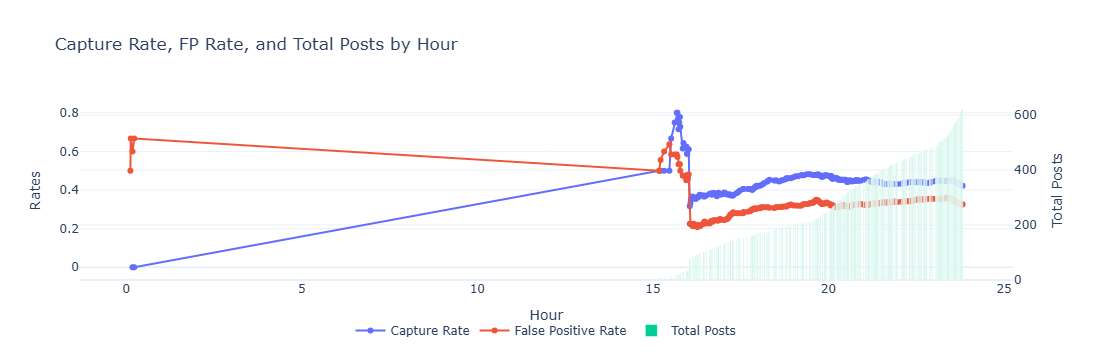

In [45]:

import plotly.graph_objects as go

fig = go.Figure()

# Capture Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["capture_rate"],
        mode="lines+markers",
        name="Capture Rate",
        yaxis="y1"
    )
)

# Bad Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["false_positive_rate"],
        mode="lines+markers",
        name="False Positive Rate",
        yaxis="y1"
    )
)

# Total Posts (secondary axis)
fig.add_trace(
    go.Bar(
        x=df_all["hour"],
        y=df_all["total_posts"],
        name="Total Posts",
        # mode="lines+markers",
        yaxis="y2",
        opacity=1
    )
)

# Layout with dual axis
fig.update_layout(
    title="Capture Rate, FP Rate, and Total Posts by Hour",
    xaxis=dict(title="Hour"),
    yaxis=dict(title="Rates", side="left"),
    yaxis2=dict(
        title="Total Posts",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",      # horizontal legend
        yanchor="top",
        y=-0.2,               # move below plot
        xanchor="center",
        x=0.5                 # center horizontally
    ),
    template="plotly_white"
)

fig.show()

In [46]:
df_all['metrics.time_cut'].max()

np.float64(1429.0)

In [47]:
print("bad_rate_test",round(bad_rate_test*100,2))
print('Rumour Capture rate: ',float(round(df_all.frauds_captured.sum()/df_all.total_fake.sum()*100,2)))
print('False Positive rate: ',float(round((df_all.records.sum()- df_all.frauds_captured.sum())/df_all.total_posts.sum()*100,2)))

bad_rate_test 38.77
Rumour Capture rate:  44.1
False Positive rate:  26.38


In [48]:
df_lgbm_all=df_all.copy()
#df_lgbm_all = df_lgbm_all[df_lgbm_all.total_posts/df_lgbm_all.total_posts.max()>=0.1]
df_lgbm_all['model']='LGBM'

#### Random Forest model

import mlflow

experiments = mlflow.search_experiments(filter_string="name LIKE '%charlie_hebdo %'")

for exp in experiments:
    print(f"ID: {exp.experiment_id}")
    print(f"Name: {exp.name}")
    print(f"Artifact Location: {exp.artifact_location}")
    print("-" * 50)

In [49]:
experiment = mlflow.get_experiment_by_name(f'Random Forest 2026-07-05 {event_name} run')
print(experiment.name)

if experiment is not None:
    experiment_id = experiment.experiment_id

    # Retrieve all runs in the experiment as a DataFrame
    df_rf = mlflow.search_runs(experiment_ids=[experiment_id]).dropna(subset='end_time')
    
    # Show the DataFrame
    #print(df)
else:
    print(f"Experiment '{experiment_name}' not found.")


Random Forest 2026-07-05 charlie_hebdo run


In [50]:
dfs=[]

for run_id in list(df_rf.run_id):
    try:
        path = mlflow.artifacts.download_artifacts(
            run_id=run_id,
            artifact_path=f"metrics_by_bucket_new_posts_{event_name}_RF.csv"
        )
        df = pd.read_csv(path)
        df["run_id"] = run_id  # track source
        #print(df.shape)
        #df["time_cut"] =df_gat[df_gat.run_id==run_id]['metrics.time_cut']

        dfs.append(df)
    except Exception:
        pass  # skip runs without the artifact

df_all = pd.concat(dfs, ignore_index=True)
df_all = df_all.merge(df_rf[['run_id','metrics.time_cut']],on='run_id',how='left')
df_all.sort_values(by='metrics.time_cut',ascending=True,inplace=True)
df_all.rename(columns={'Rumours_captured':'frauds_captured'},inplace=True)

In [51]:
df_all.sort_values(by='metrics.time_cut',ascending=True,inplace=True)

In [52]:
df_all['hour']= round(df_all['metrics.time_cut']/60,2)
df_posts_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['records'].max())
df_fakes_by_time_cut = pd.DataFrame(df_all.groupby('metrics.time_cut')['frauds_captured'].max())
df_posts_by_time_cut.rename(columns={'records':'total_posts'},inplace=True)
df_fakes_by_time_cut.rename(columns={'frauds_captured':'total_fake'},inplace=True)
df_all = df_all.merge(df_posts_by_time_cut, on='metrics.time_cut',how='left')
df_all = df_all.merge(df_fakes_by_time_cut, on='metrics.time_cut',how='left')
df_all.capture_rate = round(df_all.capture_rate,3)
df_all.false_positive_rate = round(df_all.false_positive_rate,3)
df_all = df_all[(df_all['percentile']==cut)]


In [53]:

df_all = df_all[df_all.total_posts<=20]
df_all['total_posts'] = df_all.total_posts.cumsum()
df_all['total_fake'] = df_all.total_fake.cumsum()
df_all['frauds_captured'] = df_all.frauds_captured.cumsum()
df_all['records'] = df_all.records.cumsum()
df_all['capture_rate'] = df_all['frauds_captured'] /df_all['total_fake'] 
df_all['false_positive_rate'] = (df_all['records']-df_all['frauds_captured'])/\
                    ( (df_all['records']-df_all['frauds_captured']) +  (df_all['total_posts']-df_all['records']) )


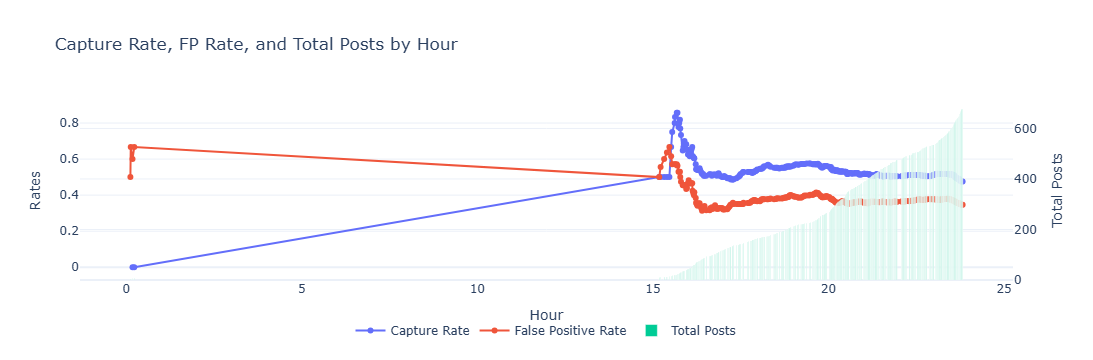

In [54]:

import plotly.graph_objects as go

fig = go.Figure()

# Capture Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["capture_rate"],
        mode="lines+markers",
        name="Capture Rate",
        yaxis="y1"
    )
)

# Bad Rate
fig.add_trace(
    go.Scatter(
        x=df_all["hour"],
        y=df_all["false_positive_rate"],
        mode="lines+markers",
        name="False Positive Rate",
        yaxis="y1"
    )
)

# Total Posts (secondary axis)
fig.add_trace(
    go.Bar(
        x=df_all["hour"],
        y=df_all["total_posts"],
        name="Total Posts",
        # mode="lines+markers",
        yaxis="y2",
        opacity=1
    )
)

# Layout with dual axis
fig.update_layout(
    title="Capture Rate, FP Rate, and Total Posts by Hour",
    xaxis=dict(title="Hour"),
    yaxis=dict(title="Rates", side="left"),
    yaxis2=dict(
        title="Total Posts",
        overlaying="y",
        side="right"
    ),
    legend=dict(
        orientation="h",      # horizontal legend
        yanchor="top",
        y=-0.2,               # move below plot
        xanchor="center",
        x=0.5                 # center horizontally
    ),
    template="plotly_white"
)

fig.show()

In [55]:
df_rf_all=df_all.copy()
#df_rf_all = df_rf_all[df_rf_all.total_posts/df_rf_all.total_posts.max()>=0.1]
df_rf_all['model']='RF'

In [56]:
print("bad_rate_test",round(bad_rate_test*100,2))
print('Rumour Capture rate: ',float(round(df_all.frauds_captured.sum()/df_all.total_fake.sum()*100,2)))
print('False Positive rate: ',float(round((df_all.records.sum()- df_all.frauds_captured.sum())/df_all.total_posts.sum()*100,2)))

bad_rate_test 38.77
Rumour Capture rate:  52.19
False Positive rate:  27.88


In [57]:
df_han_all.iloc[-1:]

,percentile,records,frauds_captured,capture_rate,bad_rate,false_positive_rate,run_id,metrics.time_cut,hour,total_posts,total_fake,model
26714,7.0,41,23.0,0.098712,0.560976,0.032086,3bc28bea54824d37b2854d6dbfdc8b11,1429.0,23.82,584,233.0,HAN


In [58]:
df_all = pd.concat([df_rf_all.iloc[-1:],df_han_all.iloc[-1:],df_gat_all.iloc[-1:],df_lgbm_all.iloc[-1:],df_lstm_all.iloc[-1:]])

TP = df_all["frauds_captured"]
FP = df_all["records"] - TP
FN = df_all["total_fake"] - TP

df_all["precision"] = TP / (TP + FP)

df_all["recall"] = df_all["capture_rate"]
df_all["f1"] = (
    2 * df_all["precision"] * df_all["recall"]
    / (df_all["precision"] + df_all["recall"])
)

result = (
    df_all.groupby("model")[
        ["recall", "precision", "f1", "capture_rate", "false_positive_rate"]
    ]
    .mean()
    .sort_values(by="f1", ascending=False)
    .round(3)
)

result

,recall,precision,f1,capture_rate,false_positive_rate
model,,,,,
LSTM,0.495,0.416,0.452,0.495,0.354
RF,0.476,0.406,0.438,0.476,0.347
GAT,0.469,0.401,0.432,0.469,0.354
LGBM,0.422,0.387,0.404,0.422,0.326
HAN,0.099,0.561,0.168,0.099,0.032


#### Creating a single dataframe with all experiments

In [59]:
df_all = pd.concat([df_rf_all,df_han_all,df_gat_all,df_lgbm_all,df_lstm_all])


In [60]:
df_all = df_all[df_all.hour>15]

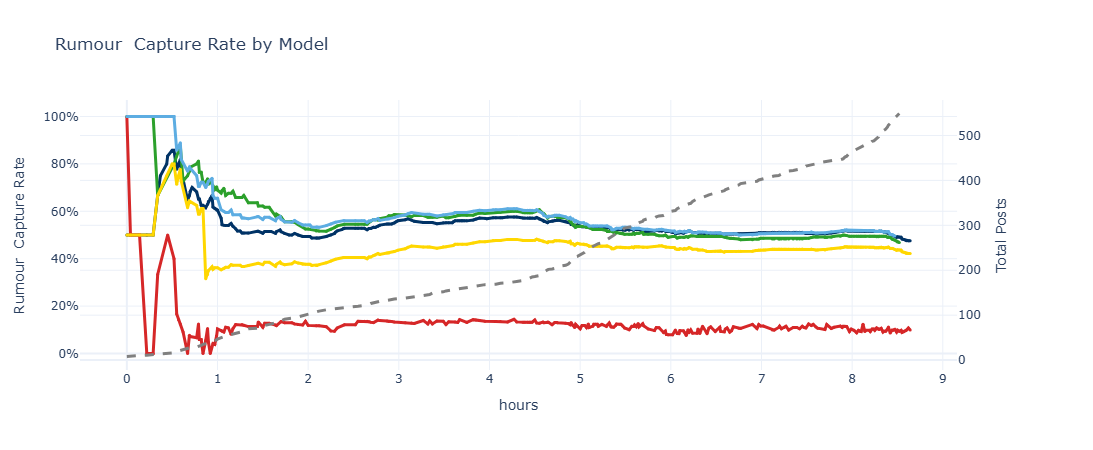

In [63]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])
model_colors = {
    "RF": "#003366",      # Dark blue
    "HAN": "#D62728",     # Red
    "LGBM": "#FFD700",    # Yellow (Gold)
    "LSTM": "#5DADE2",    # Light blue
    "GAT": "#2CA02C",     # Green
}

df_all.hour = (
    df_all.hour
    - float(
        df_all.hour.min()
    )
)

# Add one line per model
for model in df_all["model"].unique():

    df_all_model = (
        df_all[df_all["model"] == model]
        .sort_values("hour")
    )

    # Capture rate lines
    fig.add_trace(
        go.Scatter(
            x=df_all_model["hour"],
            y=df_all_model["capture_rate"],
            mode="lines+markers",
            name=model,
            line=dict(
            color=model_colors.get(model, "#808080"),
            width=3,
        ),
        marker=dict(
            color=model_colors.get(model, "#808080"),
            size=3,
        )
        ),
        secondary_y=False,
    )

    # Total posts as area plot (only once)
    if model == "GAT":
        fig.add_trace(
                    go.Scatter(
            x=df_all_model["hour"],
            y=df_all_model["total_posts"],
            mode="lines",
            line=dict(color="gray", dash="dash", width=3),
            name="Total Posts",
        ),
            secondary_y=True,
        )

fig.update_layout(
    title="Rumour  Capture Rate by Model",
    template="plotly_white",
    hovermode="x unified",
        showlegend=False,
     width=900,
    height=450
)

fig.update_xaxes(title_text="hours")

fig.update_yaxes(
    title_text="Rumour  Capture Rate",
    secondary_y=False,
    tickformat=".0%",
)

fig.update_yaxes(
    title_text="Total Posts",
    secondary_y=True,
)

fig.show()

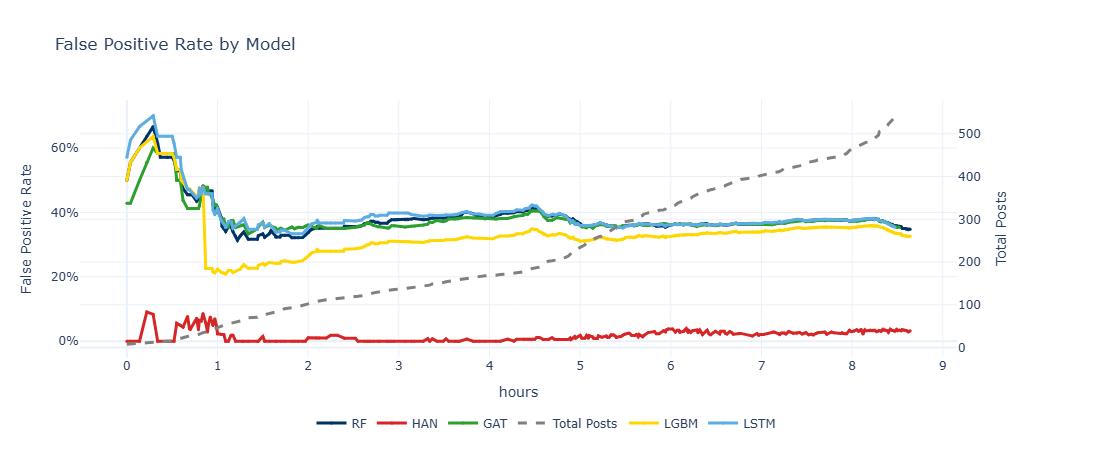

In [66]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])
model_colors = {
    "RF": "#003366",      # Dark blue
    "HAN": "#D62728",     # Red
    "LGBM": "#FFD700",    # Yellow (Gold)
    "LSTM": "#5DADE2",    # Light blue
    "GAT": "#2CA02C",     # Green
}



# Add one line per model
for model in df_all["model"].unique():

    df_all_model = (
        df_all[df_all["model"] == model]
        .sort_values("hour")
    )

    # Capture rate lines
    fig.add_trace(
        go.Scatter(
            x=df_all_model["hour"],
            y=df_all_model["false_positive_rate"],
            mode="lines+markers",
            name=model,
            line=dict(
            color=model_colors.get(model, "#808080"),
            width=3,
        ),
        marker=dict(
            color=model_colors.get(model, "#808080"),
            size=3,
        )
        ),
        secondary_y=False,
    )

    # Total posts as area plot (only once)
    if model == "GAT":
        fig.add_trace(
                    go.Scatter(
            x=df_all_model["hour"],
            y=df_all_model["total_posts"],
            mode="lines",
            line=dict(color="gray", dash="dash", width=3),
            name="Total Posts",
        ),
            secondary_y=True,
        )

fig.update_layout(
    title="False Positive Rate by Model",
    template="plotly_white",
    hovermode="x unified",
        legend=dict(
        orientation="h",      # horizontal legend
        yanchor="top",
        y=-0.2,               # place below the plot
        xanchor="center",
        x=0.5                 # center horizontally
    ),
    margin=dict(b=80) ,        # extra bottom margin for the legend,
     width=900,
    height=450
)

fig.update_xaxes(title_text="hours")

fig.update_yaxes(
    title_text="False Positive Rate",
    secondary_y=False,
    tickformat=".0%",
)

fig.update_yaxes(
    title_text="Total Posts",
    secondary_y=True,
)

fig.show()